In [1]:
#Facebook Prophet is a powerful time series forecasting tool released by Facebook in 2017. It helps analysts make accurate forecasts with minimal manual effort, especially for business data like sales, budgets, or website traffic.
#It is available as an API in both Python and R and is designed to automatically handle many complexities of time-series data such as trend changes, seasonality, and holidays.
#How Prophet Works
#Prophet uses an Additive Regression Model, which represents the time series as the sum of several components:
#𝑦(𝑡)=𝑔(𝑡)+𝑠(𝑡)+ℎ(𝑡)+𝜖𝑡y(t)=g(t)+s(t)+h(t)+ϵt
#Where each component represents a different pattern in the data.
#1.Trend Component — 
#𝑔(𝑡)g(t)
#This models the long-term growth or decline in the data.
#Prophet supports two types of trends:
#Piecewise Linear Trend – growth changes at specific points.
#Logistic Growth – growth with an upper limit (saturation).
#Key Feature
#Prophet automatically detects change points where the trend changes direction or speed.
#Example:
#Sales increasing steadily
#Suddenly slowing after market saturation
#2.Seasonality Component — 
#𝑠(𝑡)s(t)
#This models repeating patterns in the data.
#Prophet handles:
#Yearly seasonality (e.g., higher sales during festivals)
#Weekly seasonality (e.g., more traffic on weekends)
#Daily seasonality (for high-frequency data)
#Method Used
#Seasonality is modeled using a Fourier Series, which represents periodic patterns using sine and cosine waves.
#Example:
#Ice cream sales peak every summer.
#Website traffic increases every weekend.
#3.Holiday Effects — 
#ℎ(𝑡)h(t)
#Special events or holidays can affect time-series values.
#Users can provide a list of holidays, and Prophet will estimate their impact.
#Examples:
#Diwali affecting retail sales in India
#Christmas influencing e-commerce sales
#Promotional sale days
#4.Error Term — 
#𝜖𝑡ϵt
#This represents random noise or unexplained variations in the data.
#Even after modeling trend, seasonality, and holidays, some unpredictable variation remains.


In [2]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 9.0 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.1 MB 13.5 MB/s eta 0:00:01
   ----------------- ---------------------- 5.2/12.1 MB 10.8 MB/s eta 0:00:01
   -------------------- ------------------- 6.3/12.1 MB 8.6 MB/s eta 0:00:01
   ------------------------ --------------- 7.3/12.1 MB 8.0 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.1 MB 7.3 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.1 MB 6.8 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 5.6 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.1 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 4.7 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 4.4 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.1 MB 4.2 MB/s eta 0:00:01
   

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prophet as fbp
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Use fivethirtyeight plot style
plt.style.use('fivethirtyeight') 
# This code is modified by Susobhan Akhuli

In [4]:
# We will be using amazon share price data which can be downloaded from YAHOO finance website.
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Share-Price-Forecasting-Using-Facebook-Prophet---Dataset.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-27,15.315000,15.5120,15.131500,15.337500,15.337500,58406000
1,2015-01-28,15.490500,15.5755,15.190000,15.195500,15.195500,61276000
2,2015-01-29,15.236500,15.6400,14.966500,15.589000,15.589000,173132000
3,2015-01-30,17.316000,17.9750,17.037001,17.726500,17.726500,477122000
4,2015-02-02,17.502501,18.2500,17.500500,18.223499,18.223499,204638000


In [5]:
# add two columnsin dataframe having values as Date and Adj Close
df[['ds', 'y']] = df[['Date', 'Adj Close']]
# Subset two columns from data frame
df = df[['ds', 'y']]
df.head()

,ds,y
0,2015-01-27,15.337500
1,2015-01-28,15.195500
2,2015-01-29,15.589000
3,2015-01-30,17.726500
4,2015-02-02,18.223499


In [6]:
# split data frame  into two parts train and test
split_date = "2019-07-21"
df_train = df.loc[df.ds <= split_date].copy()
df_test = df.loc[df.ds > split_date].copy()

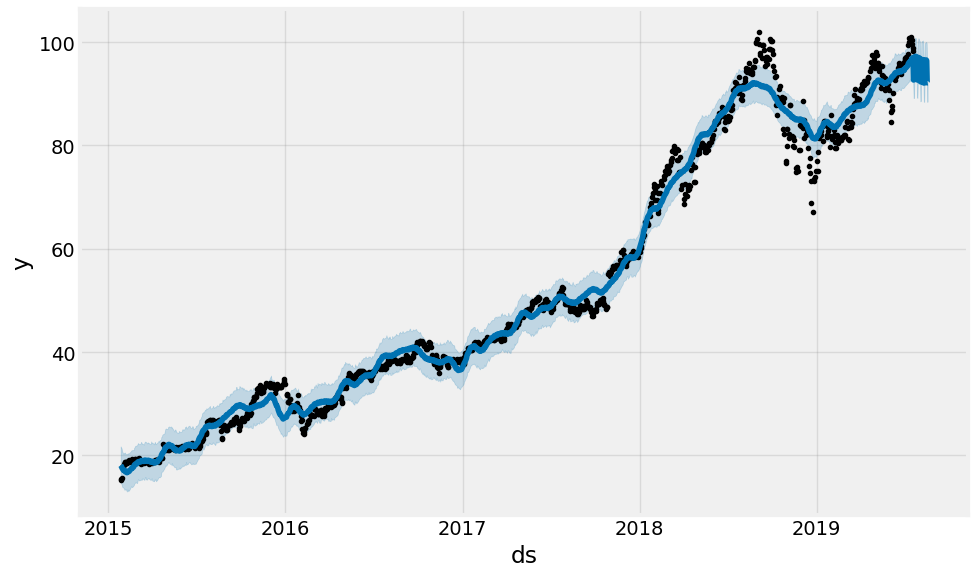

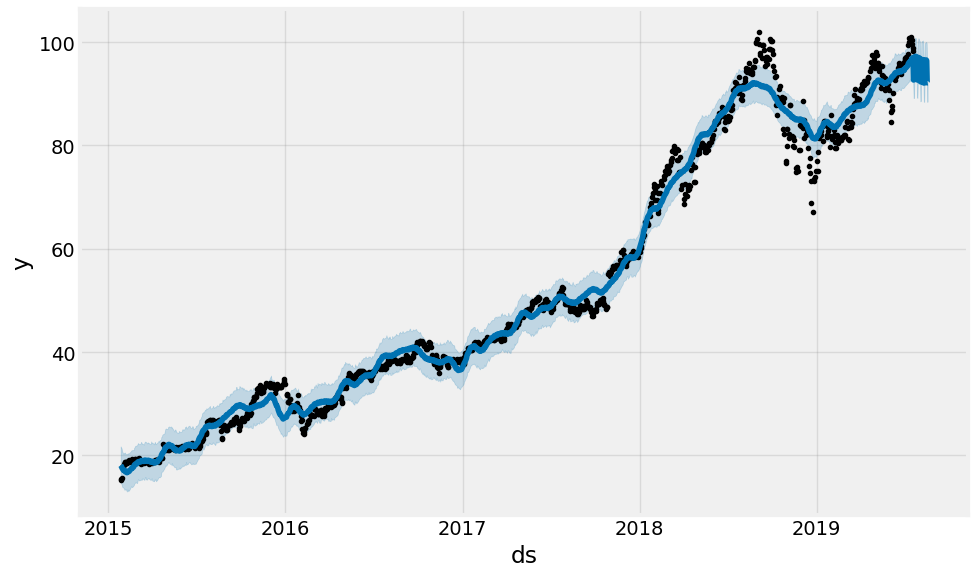

In [8]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
model.plot(forecast)

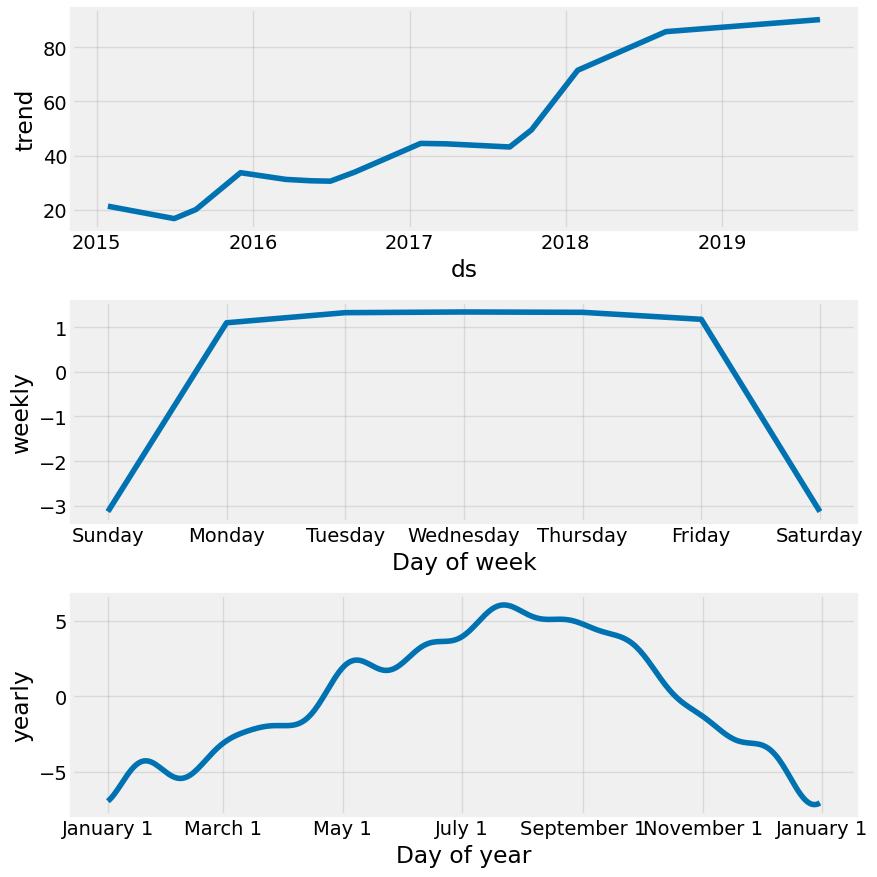

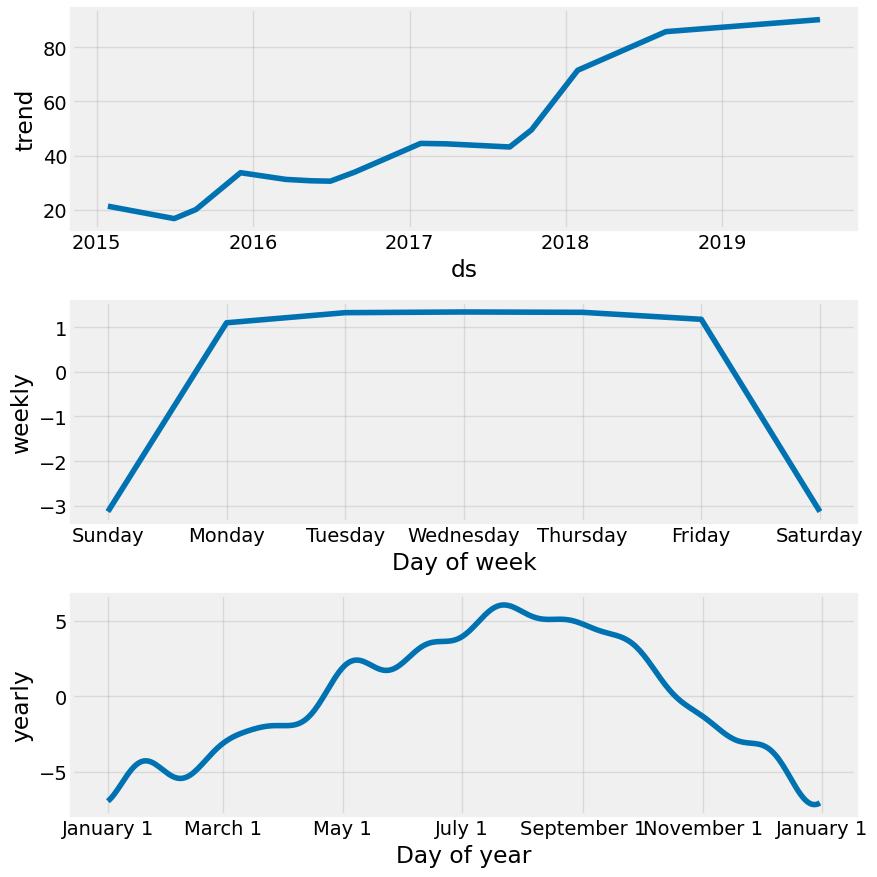

In [9]:
# plot graphs of different components:
model.plot_components(forecast)

In [13]:
forecast_test = forecast.tail(len(df_test))
print("MSE:", mean_squared_error(df_test["y"], forecast_test["yhat"]))
print("MAE:", mean_absolute_error(df_test["y"], forecast_test["yhat"]))

MSE: 6994.630519197003
MAE: 72.98446770632049


In [15]:
forecast_test = forecast.tail(len(df_test))
print("MSE:", mean_squared_error(df_test['y'], forecast_test['yhat']))
print("MAE:", mean_absolute_error(df_test['y'], forecast_test['yhat']))
def mean_abs_perc_err(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print("MAPE:", mean_abs_perc_err(df_test['y'], forecast_test['yhat']))

MSE: 6994.630519197003
MAE: 72.98446770632049
MAPE: 5.351514192453199


In [18]:
df_test['ds'] = pd.to_datetime(df_test['ds'])
df_test_pred = df_test.merge(forecast[['ds','yhat']], on='ds')
def mean_abs_perc_err(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print("MAPE:", mean_abs_perc_err(df_test_pred['y'], df_test_pred['yhat']))

MAPE: 5.207694413756289


In [19]:
forecast = model.predict(df_test)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1006,2023-07-20,107.842141,-133.292491,379.952573,-141.814607,374.345062,7.330390,7.330390,7.330390,1.331190,1.331190,1.331190,5.999200,5.999200,5.999200,0.0,0.0,0.0,115.172531
1007,2023-07-21,107.854482,-134.814509,381.074534,-142.345621,374.802081,7.210054,7.210054,7.210054,1.174981,1.174981,1.174981,6.035073,6.035073,6.035073,0.0,0.0,0.0,115.064536
1008,2023-07-24,107.891506,-136.841077,380.755862,-142.851953,375.283784,7.151554,7.151554,7.151554,1.097007,1.097007,1.097007,6.054547,6.054547,6.054547,0.0,0.0,0.0,115.043060
1009,2023-07-25,107.903847,-137.328852,382.363070,-143.382968,375.729482,7.357520,7.357520,7.357520,1.323711,1.323711,1.323711,6.033809,6.033809,6.033809,0.0,0.0,0.0,115.261367
1010,2023-07-26,107.916188,-134.587147,382.350307,-143.913982,376.161943,7.340357,7.340357,7.340357,1.339146,1.339146,1.339146,6.001211,6.001211,6.001211,0.0,0.0,0.0,115.256545


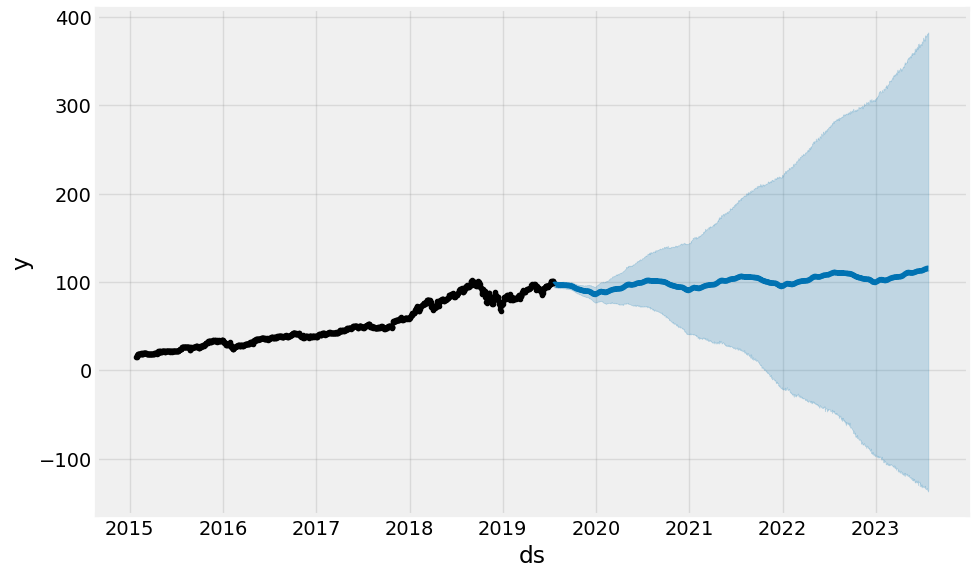

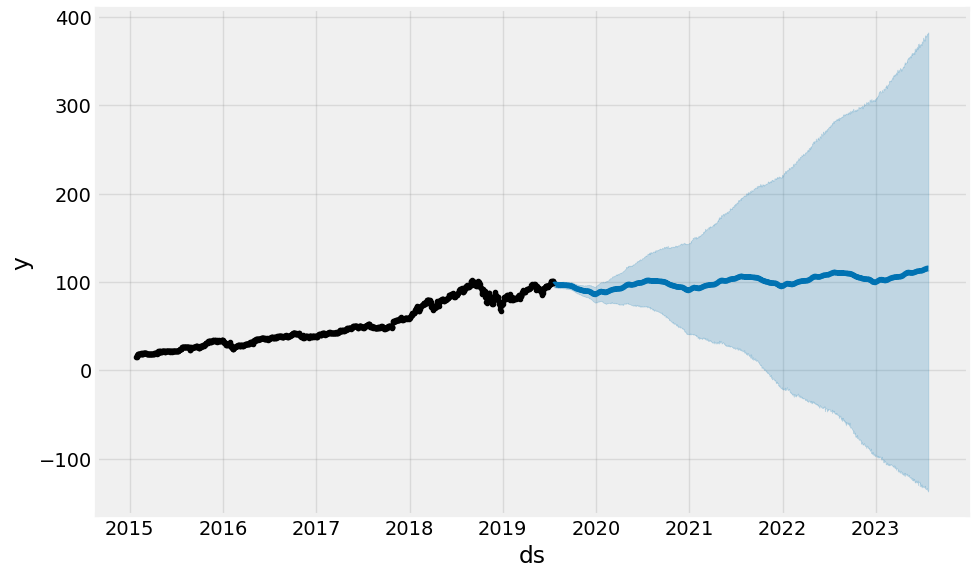

In [20]:
model.plot(forecast)